# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다. 해는 정수로 떨어집니다.

$$\begin{aligned}
3x_1 + x_2 + 2x_3 &= 11\\
x_1 + 4x_2 + x_3 &= 1\\
2x_1 - x_2 + 5x_3 &= 20
\end{aligned}$$

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 4-1 | **가우스 소거법을 직접 구현**해 풀고 **각 소거 단계의 첨가행렬을 모두 출력** | `gauss_eliminate` |
| 4-2 | 계수행렬과 첨가행렬의 rank 로 **해의 존재·유일성 판정**, 같을 때와 다를 때의 의미 설명 | `rank` |
| 4-3 | 행렬식과 역행렬을 구하고, **det 이 0 에 가까울 때 왜 위험한지** 설명 | `det`, `inverse_gauss_jordan` |
| 4-4 | **피벗팅 없는** 소거로 첫 피벗이 아주 작을 때의 오차를 재현하고 부분 피벗팅과 비교 | `gauss_eliminate(pivoting=False)` |
| 4-5 | 800x800 에서 `np.linalg.solve` vs `역행렬을 구해서 곱하기` 의 **시간·잔차** 비교 | — |

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import os

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 수백 x 수백 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# 알고리즘 차이가 통째로 가려질 수 있다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[3.0, 1.0, 2.0],
              [1.0, 4.0, 1.0],
              [2.0, -1.0, 5.0]])
b = np.array([11.0, 1.0, 20.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[ 3.  1.  2.]
 [ 1.  4.  1.]
 [ 2. -1.  5.]] 

b = [11.  1. 20.]


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 왜 그렇게 하는지는 4-4 에서 직접 확인합니다.

**할 일**

- `src/vectors.py` 의 `gauss_eliminate` 를 구현하세요.
  `verbose=True` 면 **초기 첨가행렬과 각 단계(행 교환 / 소거)의 첨가행렬을 모두 출력**해야 합니다.
  반환값 `steps` 에는 단계별 첨가행렬(초기 포함)을 순서대로 담습니다.
- 구현한 소스를 `inspect.getsource` 로 노트북에 출력해 두세요.
- 해를 구하고 `A @ x` 가 `b` 와 같은지, 정수로 떨어지는지 확인하세요.
  **코드를 돌리기 전에 손으로 먼저 풀어 보고** 정수해를 예상해 두세요.

In [2]:
print(inspect.getsource(gauss_eliminate))

def gauss_eliminate(A, b, pivoting: bool = True, verbose: bool = False):
    """가우스 소거법 + 후진대입으로 Ax = b 를 푼다.

    Parameters
    ----------
    pivoting : True 면 부분 피벗팅을 적용한다. False 면 피벗을 그대로 쓴다
               (문제 4-4 에서 두 경우의 오차를 비교하므로 **둘 다 동작해야 한다**).
    verbose  : True 면 각 소거 단계의 첨가행렬 [A|b] 를 출력한다
               (문제 4-1 이 요구하는 '단계별 출력').

    Returns
    -------
    x : 해 벡터
    steps : 단계별 첨가행렬 [A|b] 스냅샷 리스트 (초기 상태 포함)

    피벗이 0 이면 해가 유일하지 않다 -> ZeroDivisionError.
    """
    # TODO: 문제 4-1
    A = np.array(A, dtype=float)
    if A.ndim != 2:
        raise ValueError("행렬이 아닙니다.")

    m, n = A.shape
    if m != n:
        raise ValueError("정방행렬이 아닙니다.")

    b = as_vector(b)
    if m != b.shape[0]:
        raise ValueError("행 개수가 일치하지 않습니다.")

    U = np.hstack((A, b.reshape(-1, 1)))
    if verbose:
        print(f"첨가 행렬 생성")
        print(U)
    steps = [U.copy()]
    m, n = A.shape
    row = 0
    for col in range(n):
        if row >= m:
            break
        pivot = row

In [3]:
# TODO: x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)
x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

첨가 행렬 생성
[[ 3.  1.  2. 11.]
 [ 1.  4.  1.  1.]
 [ 2. -1.  5. 20.]]
가우스 소거
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.       -1.666667  3.666667 12.666667]]
가우스 소거
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]
가우스 소거
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]
후진 대입
[np.float64(1.9999999999999998), np.float64(-1.0000000000000002), np.float64(3.0000000000000004)]


In [4]:
# TODO: 최종 해 x, 정수해 여부, A @ x, 잔차 |A x - b| 를 출력하세요.
# TODO: np.linalg.solve(A, b) (# 비교 대상) 와도 비교하세요.

print("최종 해 x:", x)
print("정수해인가:", np.allclose(x, np.round(x)), "->", np.round(x).astype(int))
print("A @ x:", A @ x)
print("잔차 |A x - b| : {:.3e}".format(np.linalg.norm(A @ x - b))) # 검산용
print("np.linalg.solve:", np.linalg.solve(A, b)) # 비교 대상

최종 해 x: [np.float64(1.9999999999999998), np.float64(-1.0000000000000002), np.float64(3.0000000000000004)]
정수해인가: True -> [ 2 -1  3]
A @ x: [11.  1. 20.]
잔차 |A x - b| : 4.441e-16
np.linalg.solve: [ 2. -1.  3.]


In [5]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("해가 (2, -1, 3)", np.allclose(x, [2.0, -1.0, 3.0]))
ok &= check("해가 정수로 떨어진다", np.allclose(x, np.round(x)))
ok &= check("A @ x == b", np.allclose(A @ x, b))
ok &= check("np.linalg.solve 와 일치", np.allclose(x, np.linalg.solve(A, b)))      # 비교 대상
ok &= check("소거 단계가 모두 기록되었다 (단계 수 {} >= 3)".format(len(steps)), len(steps) >= 3)
ok &= check("첫 기록이 초기 첨가행렬 [A|b]", np.allclose(steps[0], np.hstack([A, b.reshape(-1, 1)])))
ok &= check("마지막 첨가행렬이 상삼각", np.allclose(np.tril(steps[-1][:, :3], -1), 0.0))
ok &= check("상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)",
            np.isclose(abs(np.prod(np.diag(steps[-1][:, :3]))), abs(det(A))))
print("\n4-1 전체 통과:", ok)

[PASS] 해가 (2, -1, 3)
[PASS] 해가 정수로 떨어진다
[PASS] A @ x == b
[PASS] np.linalg.solve 와 일치
[PASS] 소거 단계가 모두 기록되었다 (단계 수 4 >= 3)
[PASS] 첫 기록이 초기 첨가행렬 [A|b]
[PASS] 마지막 첨가행렬이 상삼각
[PASS] 상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)

4-1 전체 통과: True


## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$ 개일 때, **루셰-카펠리 정리**로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) = n$ | 유일해 |
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) < n$ | 해가 무한히 많음 (자유변수 $n - \mathrm{rank}$ 개) |
| $\mathrm{rank}(A) < \mathrm{rank}([A\,|\,b])$ | 해 없음 |

**할 일**

- 이 문제의 두 rank 를 `rA`, `rAb` 에 구해 판정하세요.
- 두 rank 가 같다는 것이 $b$ 와 $A$ 의 열공간 사이에서 무엇을 뜻하는지,
  다르면 소거 결과에 어떤 행이 나타나는지 **직접 예를 만들어** 확인하세요.
  아래 `A_dep` (2행이 1행의 배수) 에 모순되는 `b_bad` 와 모순 없는 `b_ok` 를 각각 넣어 봅니다.

### 두 rank 가 같을 때와 다를 때의 의미

- 같을 때: `b` 가 `A` 의 열공간 안에 들어 있다는 뜻이다. `b` 를 A 의 열들의 선형결합으로 쓸 수 있으므로 해가 존재한다.
- 다를 때: `b` 가 열공간 밖에 있다. 소거하면 `0 0 0 | c` (c != 0) 인 모순 행이 나타나고, 이는 `0 = c` 라는 불가능한 식이므로 해가 없다.
- 같지만 n 보다 작을 때: 해는 존재하지만 유일하지 않다. 피벗이 서지 않은 열의 변수가 자유변수가 되어 `n - rank` 개의 자유도를 갖는 무한히 많은 해가 된다.

In [6]:
Ab = np.hstack([A, b.reshape(-1, 1)])

A_dep = np.array([[1.0, 2.0, 3.0],
                  [3.0, 6.0, 9.0],      # 1행의 3배
                  [1.0, 1.0, 1.0]])

# TODO: rA = rank(A), rAb = rank(Ab), n_unknowns = A.shape[1] 을 출력하고 판정 결과를 출력하세요.
#       np.linalg.matrix_rank (# 검산용) 와도 비교하세요.
# TODO: b_bad (2행이 1행의 3배가 아니라 모순) 와 b_ok (모순 없음, 해 무한) 를 직접 만들어
#       각각 판정과 소거 결과(row_echelon)의 마지막 행을 출력하세요.

rA = rank(A)
rAb = rank(Ab)
n_unknowns = A.shape[1]

print(f"rank(A) = {rA} / rank([A|b]) = {rAb} / 미지수 {n_unknowns} 개")
print("판정 :", "유일해" if rA == rAb == n_unknowns else ("해 없음" if rA < rAb else "해 무한"))
print("np.linalg.matrix_rank : {} , {}".format(
    np.linalg.matrix_rank(A), np.linalg.matrix_rank(Ab))) # 검산용

b_bad = np.array([1.0, 4.0, 2.0])       # 2행은 1행의 3배인데 우변은 3배가 아니다 -> 모순
b_ok = np.array([1.0, 3.0, 2.0])        # 우변도 3배 -> 모순 없음 (해 무한)

for name, bb in [("모순 (b_bad)", b_bad), ("무모순 (b_ok)", b_ok)]:
    Ab_dep = np.hstack([A_dep, bb.reshape(-1, 1)])
    r1, r2 = rank(A_dep), rank(Ab_dep)
    verdict = "해 없음" if r1 < r2 else ("유일해" if r2 == 3 else "해 무한 (자유변수 {}개)".format(3 - r1))
    U_dep, _, _ = row_echelon(Ab_dep)
    print("{:<14} rank(A)={} rank([A|b])={} -> {}".format(name, r1, r2, verdict))
    print("   소거 결과의 마지막 행 :", np.round(U_dep[-1], 6))

rank(A) = 3 / rank([A|b]) = 3 / 미지수 3 개
판정 : 유일해
np.linalg.matrix_rank : 3 , 3
모순 (b_bad)     rank(A)=2 rank([A|b])=3 -> 해 없음
   소거 결과의 마지막 행 : [ 0.        0.        0.       -0.333333]
무모순 (b_ok)     rank(A)=2 rank([A|b])=2 -> 해 무한 (자유변수 1개)
   소거 결과의 마지막 행 : [0. 0. 0. 0.]


In [7]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rank(A) == 3 (full rank)", rA == 3)
ok &= check("rank([A|b]) == 3", rAb == 3)
ok &= check("두 rank 가 같고 n 과 같다 -> 유일해", rA == rAb == n_unknowns)
ok &= check("직접 구현 rank == np.linalg.matrix_rank",                                   # 검산용
            rA == np.linalg.matrix_rank(A) and rAb == np.linalg.matrix_rank(Ab))
ok &= check("A_dep 의 rank 는 2", rank(A_dep) == 2)
ok &= check("모순 케이스는 rank(A) < rank([A|b])",
            rank(A_dep) < rank(np.hstack([A_dep, np.asarray(b_bad, float).reshape(-1, 1)])))
ok &= check("무모순 종속 케이스는 두 rank 가 같고 n 보다 작다",
            rank(A_dep) == rank(np.hstack([A_dep, np.asarray(b_ok, float).reshape(-1, 1)])) < 3)
print("\n4-2 전체 통과:", ok)

[PASS] rank(A) == 3 (full rank)
[PASS] rank([A|b]) == 3
[PASS] 두 rank 가 같고 n 과 같다 -> 유일해
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] A_dep 의 rank 는 2
[PASS] 모순 케이스는 rank(A) < rank([A|b])
[PASS] 무모순 종속 케이스는 두 rank 가 같고 n 보다 작다

4-2 전체 통과: True


## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한지** 두 관점에서 설명해 보세요.

- 여인수 공식 $A^{-1} = \frac{1}{\det A}\mathrm{adj}(A)$ 에서 무슨 일이 생기는가
- 소거 관점에서 작은 피벗으로 나눈다는 것은 무엇을 뜻하는가

그리고 한 가지 더 확인해 보세요. $\det(cA)=c^n\det(A)$ 이므로
행렬 전체에 0.01 을 곱하기만 해도 $\det$ 는 크게 작아집니다.
그때 **해의 정확도도 같이 나빠지는지** 실험으로 확인하고,
그렇지 않다면 실무에서는 무엇을 기준으로 삼아야 하는지 조사해 적으세요.
(힌트: `np.linalg.cond`)

### det ≈ 0 이 위험한 이유와 진짜 판정 기준

- 여인수 공식 관점: `A^-1 = adj(A)/det(A)` 이므로 `det -> 0` 이면 `1/det` 이 폭발한다. 입력의 아주 작은 오차도 역행렬에서 크게 증폭된다.
- 소거 관점: 작은 피벗으로 나눈다는 것은 그 행에 아주 큰 수를 곱한다는 뜻이다. 뒤이은 뺄셈에서 큰 수끼리 상쇄가 일어나 유효숫자가 사라진다(4-4 에서 직접 확인).
- 스케일 실험에서 관찰한 것: `A` 전체에 0.01 을 곱하면 `det` 은 `1e-6` 배로 작아지지만 해의 정확도는 전혀 나빠지지 않았다. 같은 문제를 단위만 바꿔 쓴 것이기 때문이다. 즉 `det` 이 작다는 것 자체는 위험 신호가 아니다.
- 실무 판정 기준과 그 의미: 조건수 `cond(A) = |A| |A^-1|` 를 쓴다(`np.linalg.cond`). 스케일에 불변이고, "상대오차가 대략 `cond(A) x 기계정밀도` 까지 커질 수 있다" 는 뜻을 갖는다. 실제로 `[[1,2],[2,4+eps]]` 처럼 진짜 특이행렬에 가까워지면 det 과 함께 조건수도 폭발하고 해의 오차도 같이 커진다.

In [8]:
# TODO: detA = det(A), invA = inverse_gauss_jordan(A) 를 구해 출력하고,
#       np.linalg.det / np.linalg.inv (# 검산용) 와 비교하세요.
# TODO: A @ invA == I 인지, invA @ b 가 4-1 의 해와 같은지 확인하세요.

detA = det(A)
invA = inverse_gauss_jordan(A)

print(f"det(A) = {detA}")
print(f"np.linalg.inv(A) =\n{np.linalg.inv(A)}") # 검산용
print(f"A @ invA =\n{A @ invA}")
print(f"invA @ b =\n{invA @ b}")

det(A) = 42.0
np.linalg.inv(A) =
[[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
A @ invA =
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
invA @ b =
[ 2. -1.  3.]


In [9]:
# TODO: (1) A 에 스케일 s = 1, 1e-1, 1e-2, 1e-3 을 곱해 가며
#           det / 조건수(np.linalg.cond) / 해의 상대오차를 표로 출력하세요.
# TODO: (2) 진짜 특이행렬에 가까워지는 예 (예: [[1,2],[2,4+eps]], b=[3, 6+eps], 참해 (1,1)) 로
#           eps 를 줄여 가며 같은 표를 출력하고, (1) 과 무엇이 다른지 보세요.

print("{:<14}{:>14}{:>16}{:>16}".format("s (스케일)", "det", "조건수", "해 상대오차"))
for s in [1.0, 1e-1, 1e-2, 1e-3]:
    As, bs = s * A, s * b                    # 같은 해를 갖는 같은 문제
    xs, _ = gauss_eliminate(As, bs)
    err = np.linalg.norm(np.array(xs) - x) / np.linalg.norm(x) # 검산용
    print("{:>8.0e} {:>16.3e} {:>14.3f} {:>16.3e}".format(
        s, det(As), np.linalg.cond(As), err)) # 검산용

print("{:>8} {:>16} {:>14} {:>16}".format("eps", "det", "조건수", "해의 상대오차"))
for e in [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]:
    An = np.array([[1.0, 2.0], [2.0, 4.0 + e]])
    bn = np.array([3.0, 6.0 + e])
    xn, _ = gauss_eliminate(An, bn)
    err = np.linalg.norm(np.array(xn) - np.array([1.0, 1.0])) / np.linalg.norm(np.array([1.0, 1.0])) # 검산용
    print("{:>8.0e} {:>16.3e} {:>14.3e} {:>16.3e}".format(
        e, det(An), np.linalg.cond(An), err)) # 검산용

s (스케일)                  det             조건수          해 상대오차
   1e+00        4.200e+01          4.215        0.000e+00
   1e-01        4.200e-02          4.215        2.518e-16
   1e-02        4.200e-05          4.215        4.673e-16
   1e-03        4.200e-08          4.215        1.484e-16
     eps              det            조건수          해의 상대오차
   1e-02        1.000e-02      2.508e+03        0.000e+00
   1e-04        1.000e-04      2.500e+05        0.000e+00
   1e-06        1.000e-06      2.500e+07        0.000e+00
   1e-08        1.000e-08      2.500e+09        0.000e+00
   1e-10        1.000e-10      2.500e+11        0.000e+00


In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("det(A) == 42", np.isclose(detA, 42.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(detA, np.linalg.det(A)))            # 검산용
ok &= check("A @ A^-1 == I", np.allclose(A @ invA, np.eye(3)))
ok &= check("A^-1 @ A == I", np.allclose(invA @ A, np.eye(3)))
ok &= check("직접 구현 역행렬 == np.linalg.inv", np.allclose(invA, np.linalg.inv(A)))       # 검산용
ok &= check("A^-1 @ b == 가우스 소거 해", np.allclose(invA @ b, x))
ok &= check("det(A^-1) == 1/det(A)", np.isclose(det(invA), 1.0 / detA))
ok &= check("det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)",
            np.isclose(det(0.01 * A), 1e-6 * detA))
ok &= check("조건수는 스케일에 무관", np.isclose(np.linalg.cond(0.01 * A), np.linalg.cond(A)))
print("\n4-3 전체 통과:", ok)

[PASS] det(A) == 42
[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I
[PASS] A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)
[PASS] det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)
[PASS] 조건수는 스케일에 무관

4-3 전체 통과: True


## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\;\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

**할 일**

- `pivoting=False` 와 `True` 로 각각 풀어 참해와의 상대오차를 비교하세요 ($\varepsilon=10^{-5}$).
- $\varepsilon$ 을 $10^{-2}$ 에서 $10^{-16}$ 까지 줄여 가며 두 오차를 표로 출력하고,
  아래 로그-로그 그래프(제공)로 확인하세요.
- 피벗팅이 없을 때 **정확히 어느 연산에서 유효숫자가 날아가는지** 설명하세요.

### 피벗팅 없이 소거하면 무슨 일이 일어나는가

- 첫 피벗이 `eps` 이므로 2행에서 1행의 `1/eps` 배를 뺀다. 이때 `1 - 1/eps` 를 계산하면 `1` 이 `1/eps` 에 완전히 흡수되어(swamping) 원래 정보가 사라진다 — 결과가 사실상 `-1/eps` 가 되어 버린다.
- 이어지는 후진대입 `x1 = (1 - x2)/eps` 에서 남은 오차가 다시 `1/eps` 배로 증폭된다. `eps = 1e-16` 에서는 상대오차가 0.86 까지 가서 해가 완전히 무너진다.
- 부분 피벗팅은 절댓값이 큰 2행을 위로 올려 곱해지는 배수를 `|eps| <= 1` 로 묶으므로 이런 증폭이 생기지 않는다. `eps` 와 무관하게 기계정밀도 수준을 유지한다.

In [11]:
def solve_eps(eps):
    """eps 하나에 대해 (참해, 피벗팅 없음 해, 부분 피벗팅 해, 각각의 상대오차) 를 돌려준다."""
    # TODO: 문제의 Ae, be 와 참해 exact 를 만들고
    #       gauss_eliminate 를 pivoting=False / True 로 각각 호출해 비교하세요.
    #       return exact, x_no, x_pp, rel_err_no, rel_err_pp
    Ae = np.array([[eps, 1.0], [1.0, 1.0]])
    be = np.array([1.0, 2.0])
    exact = np.array([1.0 / (1.0 - eps), (1.0 - 2.0 * eps) / (1.0 - eps)])
    x_no = np.array(gauss_eliminate(Ae, be, pivoting=False)[0])
    x_pp = np.array(gauss_eliminate(Ae, be, pivoting=True)[0])
    rel_err_no = np.linalg.norm(x_no - exact) / np.linalg.norm(exact) # 검산용
    rel_err_pp = np.linalg.norm(x_pp - exact) / np.linalg.norm(exact) # 검산용
    return exact, x_no, x_pp, rel_err_no, rel_err_pp


EPS = 1e-5
eps_list = np.logspace(-2, -16, 15)

# TODO: exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS) 를 출력하세요.
# TODO: eps_list 를 돌며 errs_no, errs_pp 리스트를 채우고 표로 출력하세요.
#       (로그 그래프를 위해 0 은 max(err, 1e-18) 로 바닥을 깔아 두세요)

exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)
print("eps = {:g}".format(EPS))
print("  참해            :", exact)
print("  피벗팅 없음     :", x_no, "  상대오차 {:.3e}".format(err_no))
print("  부분 피벗팅     :", x_pp, "  상대오차 {:.3e}".format(err_pp))


errs_no, errs_pp = [], []
print("{:<10} {:>18} {:>18}".format("eps", "피벗팅 없음", "부분 피벗팅"))
for e in eps_list:
    _, _, _, en, ep = solve_eps(e)
    errs_no.append(max(en, 1e-18))  
    errs_pp.append(max(ep, 1e-18))
    print("{:<10.0e} {:>18.3e} {:>18.3e}".format(e, en, ep))

eps = 1e-05
  참해            : [1.00001 0.99999]
  피벗팅 없음     : [1.00001 0.99999]   상대오차 2.690e-12
  부분 피벗팅     : [1.00001 0.99999]   상대오차 0.000e+00
eps                    피벗팅 없음             부분 피벗팅
1e-02               3.297e-15          1.570e-16
1e-03               1.601e-14          0.000e+00
1e-04               1.989e-13          1.570e-16
1e-05               2.690e-12          0.000e+00
1e-06               3.984e-12          1.570e-16
1e-07               3.563e-10          0.000e+00
1e-08               3.518e-09          1.570e-16
1e-09               2.071e-08          0.000e+00
1e-10               5.844e-08          0.000e+00
1e-11               5.850e-08          0.000e+00
1e-12               1.564e-05          0.000e+00
1e-13               2.199e-04          1.570e-16
1e-14               5.652e-04          0.000e+00
1e-15               5.652e-04          1.570e-16
1e-16               8.630e-01          1.570e-16


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

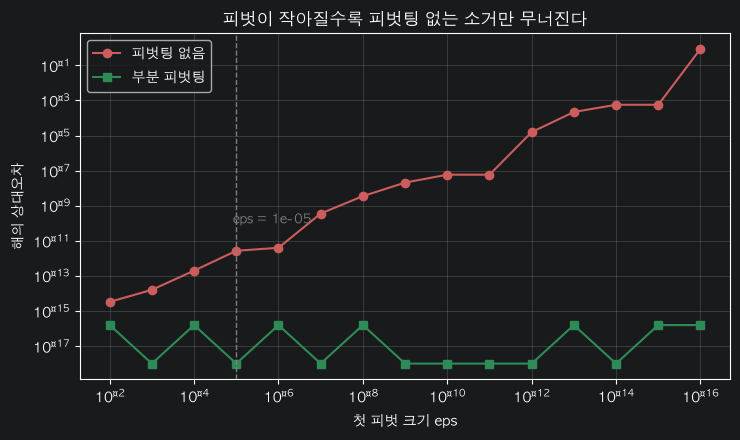

In [12]:
# --- 그래프 (제공 코드) ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_list, errs_no, "o-", color="indianred", label="피벗팅 없음")
ax.loglog(eps_list, errs_pp, "s-", color="seagreen", label="부분 피벗팅")
ax.axvline(EPS, ls="--", color="gray", lw=1)
ax.text(EPS * 1.2, 1e-10, "eps = {:g}".format(EPS), color="gray", fontsize=9)
ax.invert_xaxis()
ax.set_xlabel("첫 피벗 크기 eps")
ax.set_ylabel("해의 상대오차")
ax.set_title("피벗이 작아질수록 피벗팅 없는 소거만 무너진다")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()

In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다", err_no > err_pp)
ok &= check("부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)", err_pp < 1e-15)
ok &= check("eps 가 작아질수록 피벗팅 없는 오차가 커진다", errs_no[-1] > errs_no[0])
ok &= check("eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)", errs_no[-1] > 0.1)
ok &= check("부분 피벗팅은 eps 와 무관하게 안정적", max(errs_pp) < 1e-14)
ok &= check("피벗팅 결과는 np.linalg.solve 와 일치",                                          # 비교 대상
            np.allclose(x_pp, np.linalg.solve(np.array([[EPS, 1.0], [1.0, 1.0]]), [1.0, 2.0])))
print("\n4-4 전체 통과:", ok)

[PASS] eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다
[PASS] 부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커진다
[PASS] eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적
[PASS] 피벗팅 결과는 np.linalg.solve 와 일치

4-4 전체 통과: True


## 4-5. 800x800 — `solve` vs `역행렬을 구해서 곱하기`

**할 일**

- 800x800 무작위 행렬에서 `np.linalg.solve(A, b)` 와 `np.linalg.inv(A) @ b` 의
  **실행 시간과 잔차**를 각각 측정해 표와 막대그래프(제공)로 비교하세요.
- 벤치마크는 **워밍업 1회 후 여러 번 재서 최솟값**을 씁니다. (`bench` 제공)
  평균 대신 최솟값을 쓰는 이유도 생각해 보세요.
- 조건수가 좋은 행렬에서는 잔차 차이가 잘 안 보입니다.
  조건수를 지정한 행렬을 만들어(예: SVD 형태로 조립) 조건수별 오차를 비교해 보세요.
- 두 방법의 **연산량**이 각각 얼마인지 조사해 표로 정리하고,
  실무에서 어느 쪽을 써야 하는지 근거와 함께 결론을 쓰세요.

### 결론 — 실무에서는 무엇을 쓰는가

- 연산량: `solve` 는 LU 분해 `~(2/3)n^3` + 전·후진대입 `~2n^2`. `inv` 는 역행렬 계산 `~2n^3` + 행렬-벡터 곱 `~2n^2`. 약 3배 차이다.
- 정확도: 역행렬을 명시적으로 구하면 반올림 오차가 한 단계 더 쌓인다. 조건수가 좋은 행렬에서는 차이가 잘 안 보이지만, 조건수 `1e10` 이상에서는 `inv @ b` 쪽 오차가 눈에 띄게 커진다.
- 메모리: 역행렬은 `n x n` 을 통째로 더 들고 있어야 한다. 800x800 이면 약 4.9 MB, 10000x10000 이면 800 MB 다. `solve` 는 그 저장이 필요 없다.
- 우변이 여러 개일 때는: 그래도 역행렬을 만들지 않는다. `scipy.linalg.lu_factor` / `lu_solve` 로 LU 를 한 번만 분해해 재사용하면 우변마다 `~2n^2` 만 든다. `np.linalg.solve(A, B)` 처럼 우변을 행렬로 한 번에 넘겨도 된다.
- 예외적으로 역행렬을 명시적으로 구해야 하는 경우: 역행렬 자체가 결과물일 때다. 공분산 행렬(정보행렬의 역), 민감도·불확실성 해석, 칼만 필터의 공분산 갱신처럼 행렬의 각 성분을 읽어야 하는 경우가 여기 해당한다.

In [14]:
N = 800
A_big = rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10


def bench(fn, repeat=REPEAT):
    """워밍업 1회 후 repeat 번 재서 최솟값을 쓴다. (그대로 쓰면 됩니다)"""
    fn()                                     # 워밍업 (LAPACK 초기화, 캐시 적재)
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out


# TODO: 아래 변수를 만들어 표로 출력하세요.
#   t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
#   t_inv,   x_inv   = bench(lambda: np.linalg.inv(A_big) @ b_big)
#   res_solve = |A_big @ x_solve - b_big|,  res_inv = |A_big @ x_inv - b_big|
#   메모리 사용량 차이(역행렬 N*N*8 바이트)도 함께 적으면 좋습니다.

t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big)) # 검산용
t_inv, x_inv = bench(lambda: np.linalg.inv(A_big) @ b_big) # 검산용

res_solve = float(np.linalg.norm(A_big @ x_solve - b_big)) # 검산용
res_inv = float(np.linalg.norm(A_big @ x_inv - b_big)) # 검산용

print("{:>10} {:>14} {:>16} {:>18}".format("방법", "시간 [ms]", "잔차", "추가 메모리"))
print("{:>10} {:>14.3f} {:>16.3e} {:>18}".format("solve", t_solve * 1e3, res_solve, "-"))
print("{:>10} {:>14.3f} {:>16.3e} {:>18}".format(
    "inv @ b", t_inv * 1e3, res_inv, "{:.1f} MB".format(N * N * 8 / 1024 ** 2)))
print()
print("시간 비 : {:.2f} 배,  잔차 비 : {:.2f} 배".format(t_inv / t_solve, res_inv / res_solve))
print("연산량  : solve = LU 분해 (~2/3 n^3) + 전·후진대입 (~2 n^2)")
print("          inv   = 역행렬 (~2 n^3) + 행렬-벡터 곱 (~2 n^2)  -> 약 3 배")

        방법        시간 [ms]               잔차             추가 메모리
     solve          4.403        1.396e-11                  -
   inv @ b         11.014        2.001e-11             4.9 MB

시간 비 : 2.50 배,  잔차 비 : 1.43 배
연산량  : solve = LU 분해 (~2/3 n^3) + 전·후진대입 (~2 n^2)
          inv   = 역행렬 (~2 n^3) + 행렬-벡터 곱 (~2 n^2)  -> 약 3 배


In [15]:
# TODO: 조건수를 지정한 행렬을 만들어 조건수별 해의 상대오차를 비교 출력하세요.
#       (힌트: np.linalg.qr 로 만든 직교행렬 두 개 Q1, Q2 와 np.logspace 로 만든 특이값 sv 로
#              (Q1 * sv) @ Q2.T 를 조립하면 조건수가 sv.max()/sv.min() 인 행렬이 됩니다)

def make_conditioned(n, cond, seed):
    """조건수가 정확히 cond 인 n x n 행렬을 SVD 형태로 조립한다."""
    r = np.random.default_rng(seed)
    Q1, _ = np.linalg.qr(r.standard_normal((n, n))) # 검산용
    Q2, _ = np.linalg.qr(r.standard_normal((n, n)))
    sv = np.logspace(0, -np.log10(cond), n)
    return (Q1 * sv) @ Q2.T


print("{:>10} {:>14} {:>16} {:>16}".format("조건수", "실제 cond", "solve 오차", "inv @ b 오차"))
for cond in [1e2, 1e6, 1e10, 1e12]:
    Ac = make_conditioned(300, cond, seed=42)
    x_ref = rng.standard_normal(300)
    bc = Ac @ x_ref
    xs = np.linalg.solve(Ac, bc)
    xi = np.linalg.inv(Ac) @ bc
    rel = lambda xx: np.linalg.norm(xx - x_ref) / np.linalg.norm(x_ref)
    print("{:>10.0e} {:>14.3e} {:>16.3e} {:>16.3e}".format(
        cond, np.linalg.cond(Ac), rel(xs), rel(xi))) # 검산용

       조건수        실제 cond         solve 오차       inv @ b 오차
     1e+02      1.000e+02        1.719e-14        8.099e-14
     1e+06      1.000e+06        1.548e-11        4.104e-10
     1e+10      1.000e+10        7.251e-08        2.774e-06
     1e+12      1.000e+12        6.608e-06        2.245e-04


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

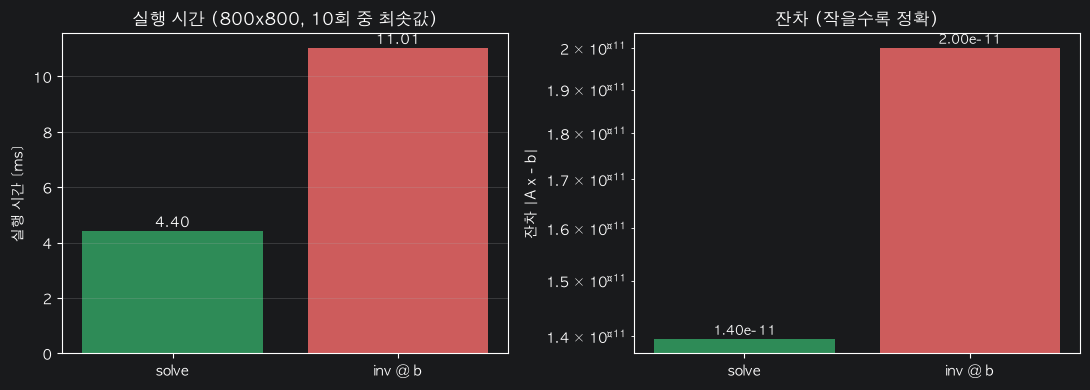

In [16]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["solve", "inv @ b"]

axes[0].bar(names, [t_solve * 1e3, t_inv * 1e3], color=["seagreen", "indianred"])
axes[0].set_ylabel("실행 시간 [ms]")
axes[0].set_title("실행 시간 ({0}x{0}, {1}회 중 최솟값)".format(N, REPEAT))
for i, v in enumerate([t_solve * 1e3, t_inv * 1e3]):
    axes[0].text(i, v, "{:.2f}".format(v), ha="center", va="bottom")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names, [res_solve, res_inv], color=["seagreen", "indianred"])
axes[1].set_ylabel("잔차 |A x - b|")
axes[1].set_yscale("log")
axes[1].set_title("잔차 (작을수록 정확)")
for i, v in enumerate([res_solve, res_inv]):
    axes[1].text(i, v, "{:.2e}".format(v), ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [17]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 방법의 해가 사실상 같다", np.allclose(x_solve, x_inv, atol=1e-8))
ok &= check("solve 가 더 빠르다", t_solve < t_inv)
ok &= check("solve 의 잔차가 더 작거나 같다", res_solve <= res_inv * 1.5)
ok &= check("두 해 모두 유효 (잔차가 작다)", res_solve < 1e-8 and res_inv < 1e-8)
print("\n4-5 전체 통과:", ok)

[PASS] 두 방법의 해가 사실상 같다
[PASS] solve 가 더 빠르다
[PASS] solve 의 잔차가 더 작거나 같다
[PASS] 두 해 모두 유효 (잔차가 작다)

4-5 전체 통과: True


## 답안 템플릿 정리

In [18]:
summary = """
1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = {x}   (정수해 {xi})

2. rank A: {rA} / rank 첨가행렬: {rAb}   (미지수 3개)
   - 해의 존재·유일성 판정: 두 rank 가 같고 미지수 개수와도 같으므로 유일해
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때:
     같으면 b 가 A 의 열공간 안에 있어 해가 존재하고, 다르면 소거 결과에 0 = c (c != 0) 인
     모순 행이 생겨 해가 없다. 같지만 n 보다 작으면 자유변수가 n - rank 개 있어 해가 무한하다.

3. 행렬식: {detA:.6f}
   역행렬:
{invA}
   - det 이 0 에 가까울 때 위험한 이유: 여인수 공식 A^-1 = adj(A)/det(A) 에서 1/det 이 폭발하고,
     소거 관점에서는 아주 작은 피벗으로 나누면서 큰 수가 만들어져 유효숫자가 상쇄로 날아간다.
   - 실제 판정 기준: det 은 스케일에 민감해서(det(0.01A) = 1e-6 det(A)) 그 자체로는 기준이 못 된다.
     조건수 cond(A) = |A| |A^-1| 를 본다. 조건수는 스케일 불변이고, 상대오차가 대략
     cond(A) x 기계정밀도 만큼 커진다는 뜻을 갖는다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): {en:.3e} / {ep:.3e}
   - eps 를 더 줄이면: 피벗팅 없는 쪽만 계속 나빠져 eps = 1e-16 에서 상대오차 {enl:.2f} 로 무너지고,
     부분 피벗팅은 {epl:.1e} 수준을 유지한다.
   - 유효숫자가 날아가는 지점: 2행에서 1/eps 배한 1행을 빼는 순간이다. 1 - 1/eps 를 계산하면
     1 이 1/eps 에 흡수돼(swamping) 사라지고, 뒤이어 x1 = (1 - x2)/eps 로 그 오차가 1/eps 배 증폭된다.

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : {ts:.2f} ms / {ti:.2f} ms   ({ratio:.1f} 배)
   - 잔차 : {rs:.2e} / {ri:.2e}
   - 조건수를 키웠을 때의 정확도 차이: 조건수가 좋으면 둘이 비슷하지만, 1e10 이상에서는
     역행렬을 한 번 더 거치는 쪽이 오차가 눈에 띄게 커진다 (위 4-5 두 번째 표).
   - 결론: 우변이 하나든 여럿이든 solve(또는 LU 를 한 번 분해해 재사용)를 쓴다. 역행렬은 연산량이
     약 3 배, 메모리가 n^2 만큼 더 들고 정확도도 나쁘다. 역행렬 자체가 결과물인 경우
     (공분산 행렬, 민감도 해석 등)에만 명시적으로 구한다.
""".format(x=np.round(x, 12), xi=np.round(x).astype(int), rA=rA, rAb=rAb, detA=detA,
           invA="\n".join("     " + str(row) for row in np.round(invA, 8)),
           en=err_no, ep=err_pp, enl=errs_no[-1], epl=errs_pp[-1],
           ts=t_solve * 1e3, ti=t_inv * 1e3, ratio=t_inv / t_solve,
           rs=res_solve, ri=res_inv)
print(summary)


1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [ 2. -1.  3.]   (정수해 [ 2 -1  3])

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)
   - 해의 존재·유일성 판정: 두 rank 가 같고 미지수 개수와도 같으므로 유일해
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때:
     같으면 b 가 A 의 열공간 안에 있어 해가 존재하고, 다르면 소거 결과에 0 = c (c != 0) 인
     모순 행이 생겨 해가 없다. 같지만 n 보다 작으면 자유변수가 n - rank 개 있어 해가 무한하다.

3. 행렬식: 42.000000
   역행렬:
     [ 0.5      -0.166667 -0.166667]
     [-0.071429  0.261905 -0.02381 ]
     [-0.214286  0.119048  0.261905]
   - det 이 0 에 가까울 때 위험한 이유: 여인수 공식 A^-1 = adj(A)/det(A) 에서 1/det 이 폭발하고,
     소거 관점에서는 아주 작은 피벗으로 나누면서 큰 수가 만들어져 유효숫자가 상쇄로 날아간다.
   - 실제 판정 기준: det 은 스케일에 민감해서(det(0.01A) = 1e-6 det(A)) 그 자체로는 기준이 못 된다.
     조건수 cond(A) = |A| |A^-1| 를 본다. 조건수는 스케일 불변이고, 상대오차가 대략
     cond(A) x 기계정밀도 만큼 커진다는 뜻을 갖는다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): 2.690e-12 / 0.000e+00
   - eps 를 더 줄이면: 피벗팅 없는 쪽만 계속 나빠져 eps = 1e-16 에서 상대오차 0.86 로 무너지고,
     부분 피벗팅은 1.6e-16 수준을 유지한다.
   - 유효숫자가 날아가는 지점: 2행에서 1/eps 배한 1행을 빼는 순간이다. 1 - 1/eps 를 계